In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn

In [2]:
from google.colab import files

uploaded = files.upload()

Saving online_retail_II.xlsx to online_retail_II.xlsx


In [3]:
import pandas as pd

file_name = "online_retail_II.xlsx"

df = pd.read_excel(file_name)

print("File loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

File loaded successfully!
Rows: 525461
Columns: 8


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [4]:
xls = pd.ExcelFile(file_name)

print("Available Sheets:")
print(xls.sheet_names)

Available Sheets:
['Year 2009-2010', 'Year 2010-2011']


In [6]:
file_name = "online_retail_II.xlsx"

# Load both sheets
sheets = pd.read_excel(file_name, sheet_name=None)

# Combine both sheets into one DataFrame
df = pd.concat(sheets.values(), ignore_index=True)

print("Full dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Full dataset loaded successfully!
Rows: 1067371
Columns: 8


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [7]:
#Advanced Data Preprocessing & Feature Engineering
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


In [8]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64


In [9]:
#Duplicate Records Check
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 34335


In [10]:
# Remove duplicate rows
df = df.drop_duplicates().reset_index(drop=True)

print("Duplicate rows removed successfully!")
print("Remaining rows:", df.shape[0])

Duplicate rows removed successfully!
Remaining rows: 1033036


In [11]:
# Check missing values after removing duplicates
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": missing_percentage.round(2)
})

print(missing_summary)

             Missing Values  Missing Percentage
Invoice                   0                0.00
StockCode                 0                0.00
Description            4275                0.41
Quantity                  0                0.00
InvoiceDate               0                0.00
Price                     0                0.00
Customer ID          235151               22.76
Country                   0                0.00


In [12]:
# Remove rows with missing Description or Customer ID
df = df.dropna(subset=["Description", "Customer ID"]).reset_index(drop=True)

print("Missing values handled successfully!")
print("Remaining rows:", df.shape[0])

print("\nMissing values after cleaning:")
print(df.isnull().sum())

Missing values handled successfully!
Remaining rows: 797885

Missing values after cleaning:
Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64


In [13]:
# Check invalid Quantity and Price values

print("Quantity <= 0:", (df["Quantity"] <= 0).sum())
print("Price <= 0:", (df["Price"] <= 0).sum())

Quantity <= 0: 18390
Price <= 0: 70


In [14]:
# Remove invalid transaction records
df = df[(df["Quantity"] > 0) & (df["Price"] > 0)].reset_index(drop=True)

print("Invalid records removed successfully!")
print("Remaining rows:", df.shape[0])

print("Quantity <= 0:", (df["Quantity"] <= 0).sum())
print("Price <= 0:", (df["Price"] <= 0).sum())

Invalid records removed successfully!
Remaining rows: 779425
Quantity <= 0: 0
Price <= 0: 0


In [15]:
print("Final Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

Final Dataset Shape: (779425, 8)

Missing Values:
Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64

Duplicate Rows:
0

Data Types:
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object


In [16]:
# Create Revenue feature
df["Revenue"] = df["Quantity"] * df["Price"]

print("Revenue feature created successfully!")

df[["Quantity", "Price", "Revenue"]].head()

Revenue feature created successfully!


,Quantity,Price,Revenue
0,12,6.95,83.4
1,12,6.75,81.0
2,12,6.75,81.0
3,48,2.10,100.8
4,24,1.25,30.0


In [17]:
# Create date-based features

df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month
df["Month_Name"] = df["InvoiceDate"].dt.month_name()
df["Quarter"] = df["InvoiceDate"].dt.quarter
df["Day"] = df["InvoiceDate"].dt.day
df["DayOfWeek"] = df["InvoiceDate"].dt.dayofweek
df["Day_Name"] = df["InvoiceDate"].dt.day_name()
df["Hour"] = df["InvoiceDate"].dt.hour
df["Is_Weekend"] = df["DayOfWeek"] >= 5

print("Date-based features created successfully!")

df[[
    "InvoiceDate",
    "Year",
    "Month",
    "Month_Name",
    "Quarter",
    "Day",
    "DayOfWeek",
    "Day_Name",
    "Hour",
    "Is_Weekend"
]].head()

Date-based features created successfully!


,InvoiceDate,Year,Month,Month_Name,Quarter,Day,DayOfWeek,Day_Name,Hour,Is_Weekend
0,2009-12-01 07:45:00,2009,12,December,4,1,1,Tuesday,7,False
1,2009-12-01 07:45:00,2009,12,December,4,1,1,Tuesday,7,False
2,2009-12-01 07:45:00,2009,12,December,4,1,1,Tuesday,7,False
3,2009-12-01 07:45:00,2009,12,December,4,1,1,Tuesday,7,False
4,2009-12-01 07:45:00,2009,12,December,4,1,1,Tuesday,7,False


In [18]:
print("Final Dataset Shape:", df.shape)

print("\nFinal Columns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

Final Dataset Shape: (779425, 18)

Final Columns:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country', 'Revenue', 'Year', 'Month', 'Month_Name', 'Quarter', 'Day', 'DayOfWeek', 'Day_Name', 'Hour', 'Is_Weekend']

Missing Values:
Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
Revenue        0
Year           0
Month          0
Month_Name     0
Quarter        0
Day            0
DayOfWeek      0
Day_Name       0
Hour           0
Is_Weekend     0
dtype: int64


In [21]:
#Use Python libraries such as Pandas, NumPy, Matplotlib, and Scikit-learn.
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)
print("Matplotlib version:", plt.matplotlib.__version__)
print("Scikit-learn version:", sklearn.__version__)

print("\nAll required libraries imported successfully!")

Pandas version: 2.2.3
NumPy version: 2.1.3
Matplotlib version: 3.10.0
Scikit-learn version: 1.6.1

All required libraries imported successfully!


In [22]:
# NumPy numerical analysis

revenue_array = df["Revenue"].to_numpy()

print("Total Revenue:", np.sum(revenue_array))
print("Average Revenue per Transaction:", np.mean(revenue_array))
print("Maximum Revenue:", np.max(revenue_array))
print("Minimum Revenue:", np.min(revenue_array))

Total Revenue: 17374804.268000003
Average Revenue per Transaction: 22.29182316194631
Maximum Revenue: 168469.6
Minimum Revenue: 0.001


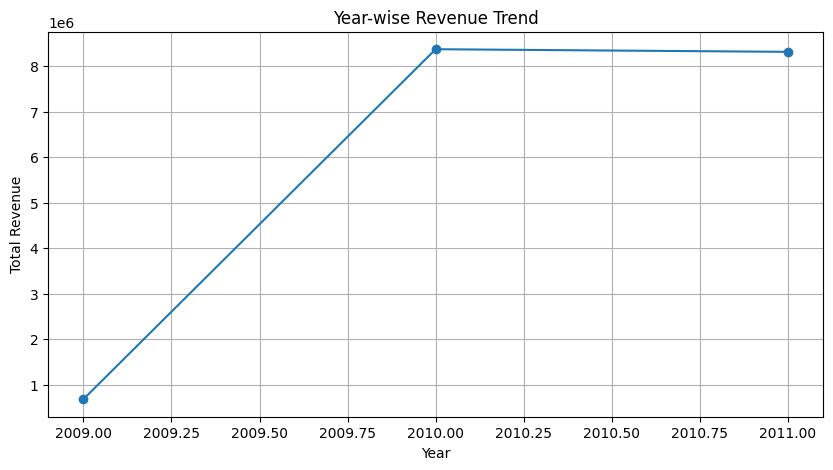

In [23]:
# Matplotlib visualization - Year-wise Revenue

yearly_revenue = df.groupby("Year")["Revenue"].sum()

plt.figure(figsize=(10, 5))
plt.plot(yearly_revenue.index, yearly_revenue.values, marker="o")
plt.title("Year-wise Revenue Trend")
plt.xlabel("Year")
plt.ylabel("Total Revenue")
plt.grid(True)
plt.show()

In [24]:
# Scikit-learn - Prepare data for predictive modeling

from sklearn.model_selection import train_test_split

X = df[["Quantity", "Price"]]
y = df["Revenue"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)
print("Scikit-learn train-test split completed successfully!")


Training data: (623540, 2)
Testing data: (155885, 2)
Scikit-learn train-test split completed successfully!


In [25]:
# Predictive Analytics Model

from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [26]:
# Generate Revenue predictions

y_pred = model.predict(X_test)

print("Predictions generated successfully!")
print("\nFirst 10 Actual vs Predicted Revenue:")

comparison = pd.DataFrame({
    "Actual Revenue": y_test.values[:10],
    "Predicted Revenue": y_pred[:10]
})

print(comparison)

Predictions generated successfully!

First 10 Actual vs Predicted Revenue:
   Actual Revenue  Predicted Revenue
0           45.90          17.180078
1            7.80           8.441615
2          159.20          32.774541
3            4.20           5.976909
4           17.00          28.266508
5            1.70           4.636363
6            3.75           6.433644
7           20.00          23.444340
8          120.96         379.631962
9           10.50          34.369289


In [28]:
# Evaluate the predictive model

from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Model Performance:")
print("R² Score:", r2)
print("RMSE:", rmse)

Model Performance:
R² Score: 0.03733519769029836
RMSE: 70.04684571966253


In [29]:
# Prepare monthly revenue for business forecasting

monthly_revenue = (
    df.groupby(df["InvoiceDate"].dt.to_period("M"))["Revenue"]
      .sum()
      .reset_index()
)

monthly_revenue["InvoiceDate"] = monthly_revenue["InvoiceDate"].dt.to_timestamp()

print("Monthly Revenue Dataset:")
print(monthly_revenue)

print("\nNumber of months:", len(monthly_revenue))

Monthly Revenue Dataset:
   InvoiceDate      Revenue
0   2009-12-01   683504.010
1   2010-01-01   555802.672
2   2010-02-01   504558.956
3   2010-03-01   696978.471
4   2010-04-01   591982.002
5   2010-05-01   597833.380
6   2010-06-01   636371.130
7   2010-07-01   589736.170
8   2010-08-01   602224.600
9   2010-09-01   829013.951
10  2010-10-01  1033112.010
11  2010-11-01  1166460.022
12  2010-12-01   570422.730
13  2011-01-01   568101.310
14  2011-02-01   446084.920
15  2011-03-01   594081.760
16  2011-04-01   468374.331
17  2011-05-01   677355.150
18  2011-06-01   660046.050
19  2011-07-01   598962.901
20  2011-08-01   644051.040
21  2011-09-01   950690.202
22  2011-10-01  1035642.450
23  2011-11-01  1156205.610
24  2011-12-01   517208.440

Number of months: 25


In [30]:
# Create time-based features for forecasting

monthly_revenue["Year"] = monthly_revenue["InvoiceDate"].dt.year
monthly_revenue["Month"] = monthly_revenue["InvoiceDate"].dt.month

print("Forecasting features created successfully!")
print(monthly_revenue.head())

Forecasting features created successfully!
  InvoiceDate     Revenue  Year  Month
0  2009-12-01  683504.010  2009     12
1  2010-01-01  555802.672  2010      1
2  2010-02-01  504558.956  2010      2
3  2010-03-01  696978.471  2010      3
4  2010-04-01  591982.002  2010      4


In [31]:
# Split monthly data chronologically

train_data = monthly_revenue.iloc[:-5].copy()
test_data = monthly_revenue.iloc[-5:].copy()

X_train_forecast = train_data[["Year", "Month"]]
y_train_forecast = train_data["Revenue"]

X_test_forecast = test_data[["Year", "Month"]]
y_test_forecast = test_data["Revenue"]

print("Training months:", len(train_data))
print("Testing months:", len(test_data))

print("\nTraining period:")
print(train_data["InvoiceDate"].min(), "to", train_data["InvoiceDate"].max())

print("\nTesting period:")
print(test_data["InvoiceDate"].min(), "to", test_data["InvoiceDate"].max())

Training months: 20
Testing months: 5

Training period:
2009-12-01 00:00:00 to 2011-07-01 00:00:00

Testing period:
2011-08-01 00:00:00 to 2011-12-01 00:00:00


In [32]:
# Train the forecasting model

forecast_model = LinearRegression()

forecast_model.fit(
    X_train_forecast,
    y_train_forecast
)

print("Forecasting model trained successfully!")

Forecasting model trained successfully!


In [33]:
# Predict monthly revenue for the testing period

forecast_predictions = forecast_model.predict(X_test_forecast)

forecast_result = test_data[["InvoiceDate", "Revenue"]].copy()

forecast_result["Predicted_Revenue"] = forecast_predictions

print("Revenue predictions generated successfully!")
print(forecast_result)

Revenue predictions generated successfully!
   InvoiceDate      Revenue  Predicted_Revenue
20  2011-08-01   644051.040      711077.431038
21  2011-09-01   950690.202      740059.676580
22  2011-10-01  1035642.450      769041.922123
23  2011-11-01  1156205.610      798024.167666
24  2011-12-01   517208.440      827006.413208


In [34]:
# Evaluate the forecasting model

forecast_r2 = r2_score(y_test_forecast, forecast_predictions)
forecast_rmse = np.sqrt(
    mean_squared_error(y_test_forecast, forecast_predictions)
)

print("Forecasting Model Performance:")
print("R² Score:", forecast_r2)
print("RMSE:", forecast_rmse)

Forecasting Model Performance:
R² Score: -0.1830296680525736
RMSE: 262374.6659397983


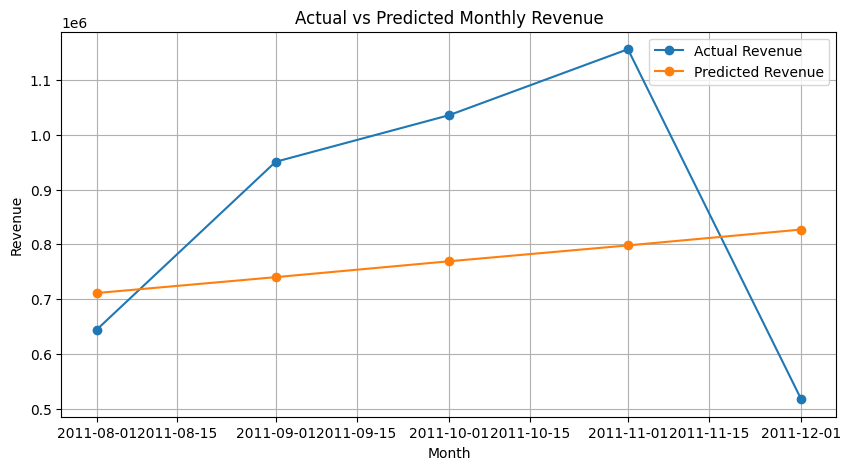

In [35]:
# Visualize actual vs predicted revenue

plt.figure(figsize=(10, 5))

plt.plot(
    forecast_result["InvoiceDate"],
    forecast_result["Revenue"],
    marker="o",
    label="Actual Revenue"
)

plt.plot(
    forecast_result["InvoiceDate"],
    forecast_result["Predicted_Revenue"],
    marker="o",
    label="Predicted Revenue"
)

plt.title("Actual vs Predicted Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.legend()
plt.grid(True)

plt.show()

In [36]:
# KPI Summary

total_revenue = df["Revenue"].sum()
total_quantity = df["Quantity"].sum()
total_transactions = df["Invoice"].nunique()
total_customers = df["Customer ID"].nunique()

kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Revenue",
        "Total Quantity Sold",
        "Total Transactions",
        "Total Customers"
    ],
    "Value": [
        total_revenue,
        total_quantity,
        total_transactions,
        total_customers
    ]
})

print("KPI Summary:")
print(kpi_summary)

KPI Summary:
                   KPI         Value
0        Total Revenue  1.737480e+07
1  Total Quantity Sold  1.051395e+07
2   Total Transactions  3.696900e+04
3      Total Customers  5.878000e+03


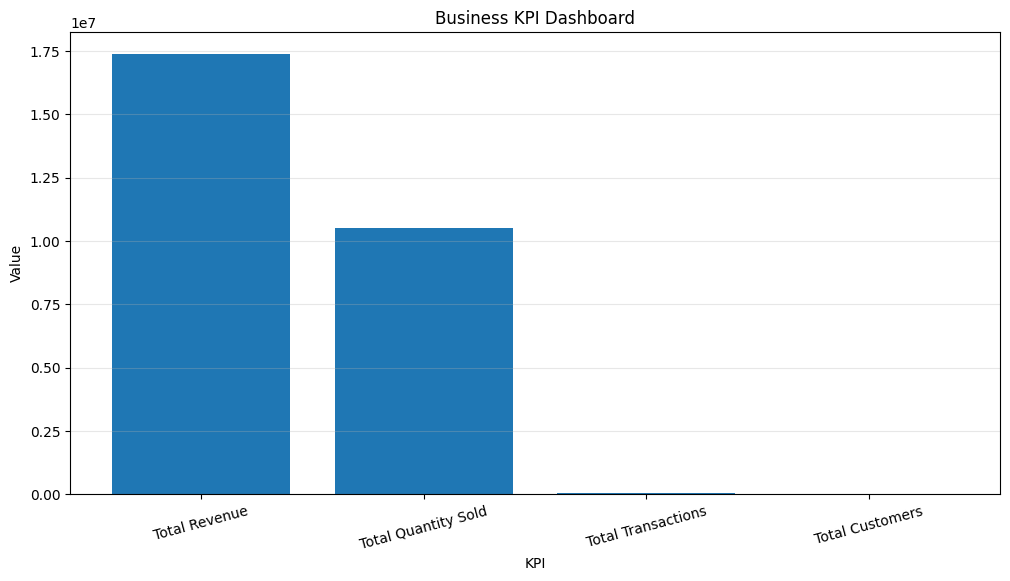

In [37]:
# KPI Dashboard

plt.figure(figsize=(12, 6))

kpi_names = [
    "Total Revenue",
    "Total Quantity Sold",
    "Total Transactions",
    "Total Customers"
]

kpi_values = [
    total_revenue,
    total_quantity,
    total_transactions,
    total_customers
]

plt.bar(kpi_names, kpi_values)

plt.title("Business KPI Dashboard")
plt.xlabel("KPI")
plt.ylabel("Value")
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.3)

plt.show()

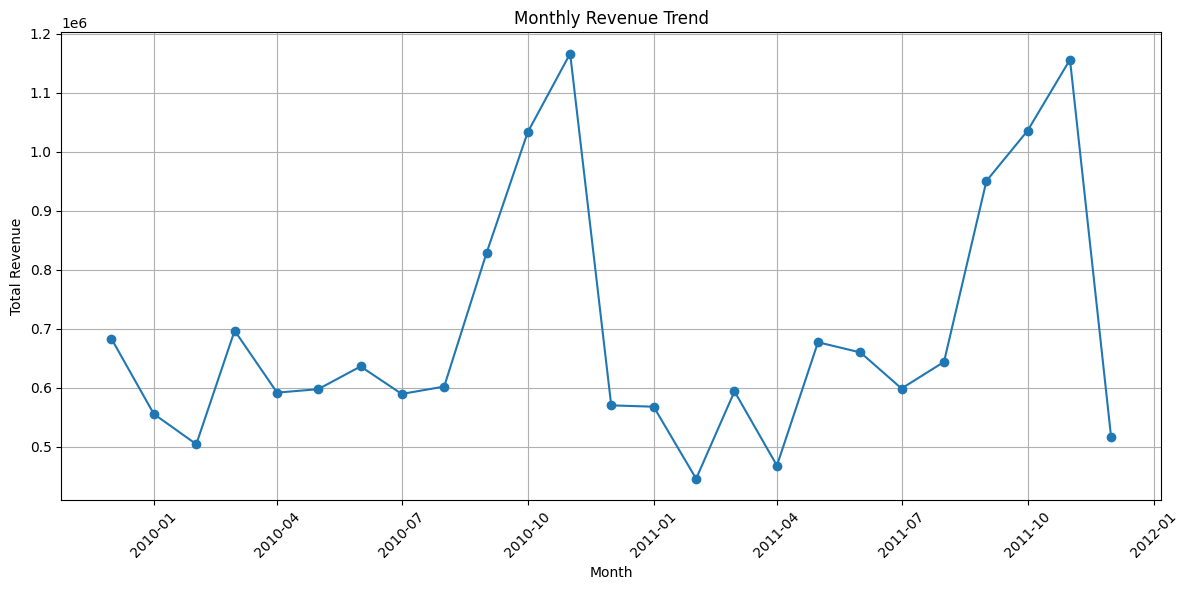

In [38]:
# Task 5 - Monthly Revenue Trend

monthly_revenue_dashboard = (
    df.groupby(df["InvoiceDate"].dt.to_period("M"))["Revenue"]
      .sum()
      .reset_index()
)

monthly_revenue_dashboard["InvoiceDate"] = (
    monthly_revenue_dashboard["InvoiceDate"].dt.to_timestamp()
)

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_revenue_dashboard["InvoiceDate"],
    monthly_revenue_dashboard["Revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

In [39]:
# Customer Revenue Analysis

customer_revenue = (
    df.groupby("Customer ID")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

print("Top 10 Customers by Revenue:")
print(customer_revenue.head(10))

Top 10 Customers by Revenue:
Customer ID
18102.0    580987.04
14646.0    528602.52
14156.0    313437.62
14911.0    291420.81
17450.0    244784.25
13694.0    195640.69
17511.0    172132.87
16446.0    168472.50
16684.0    147142.77
12415.0    144458.37
Name: Revenue, dtype: float64


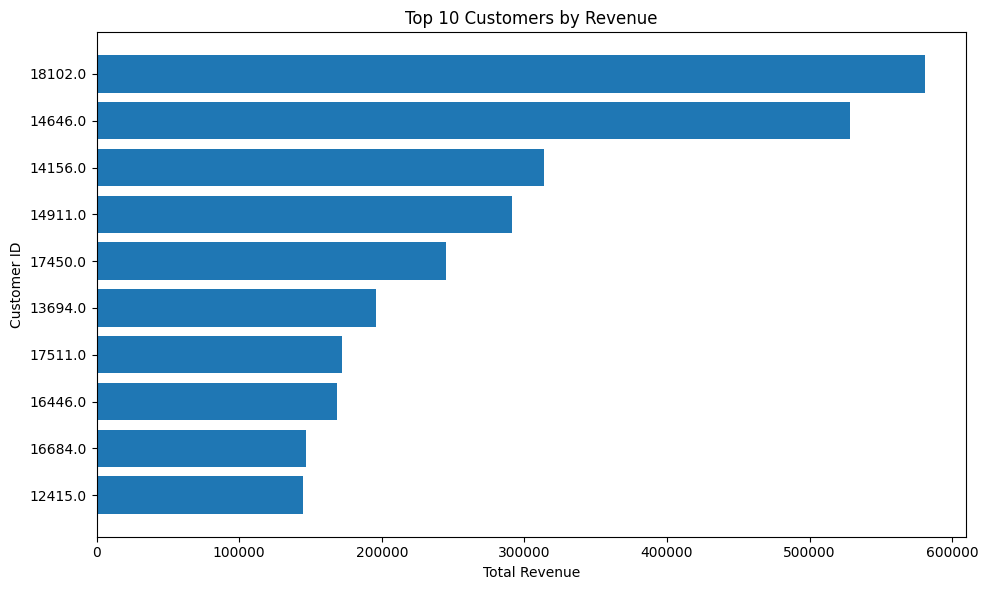

In [40]:
# Top 10 Customers Revenue Visualization

top_10_customers = customer_revenue.head(10).sort_values()

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_customers.index.astype(str),
    top_10_customers.values
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Customer ID")

plt.tight_layout()
plt.show()

In [41]:
# Country-wise Revenue Analysis

country_revenue = (
    df.groupby("Country")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

print("Top 10 Countries by Revenue:")
print(country_revenue.head(10))

Top 10 Countries by Revenue:
Country
United Kingdom    1.438923e+07
EIRE              6.165705e+05
Netherlands       5.540381e+05
Germany           4.250197e+05
France            3.487690e+05
Australia         1.692835e+05
Spain             1.083325e+05
Switzerland       1.000619e+05
Sweden            9.151582e+04
Denmark           6.858069e+04
Name: Revenue, dtype: float64


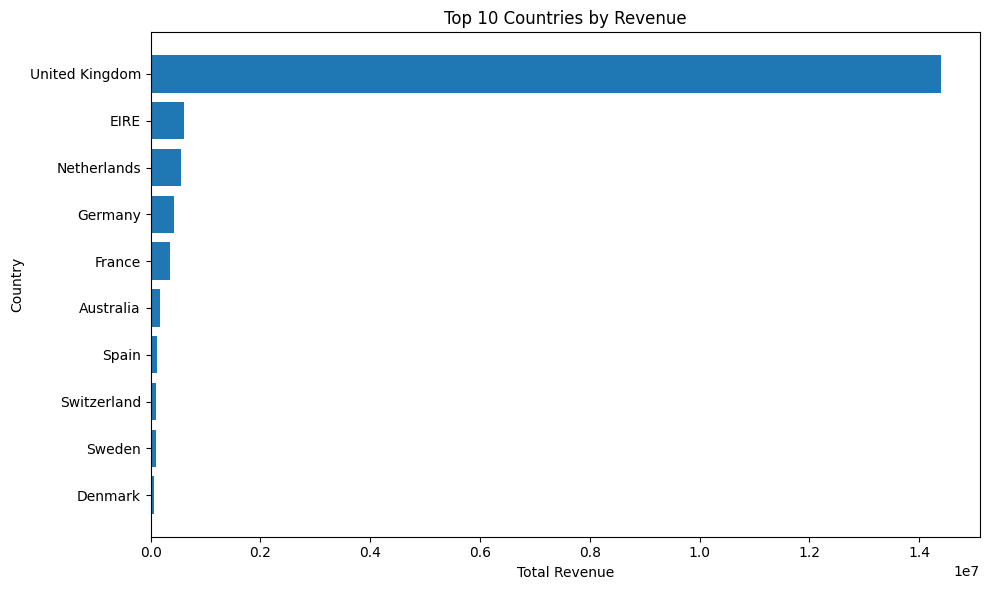

In [42]:
# Top 10 Countries Revenue Visualization

top_10_countries = country_revenue.head(10).sort_values()

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_countries.index,
    top_10_countries.values
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

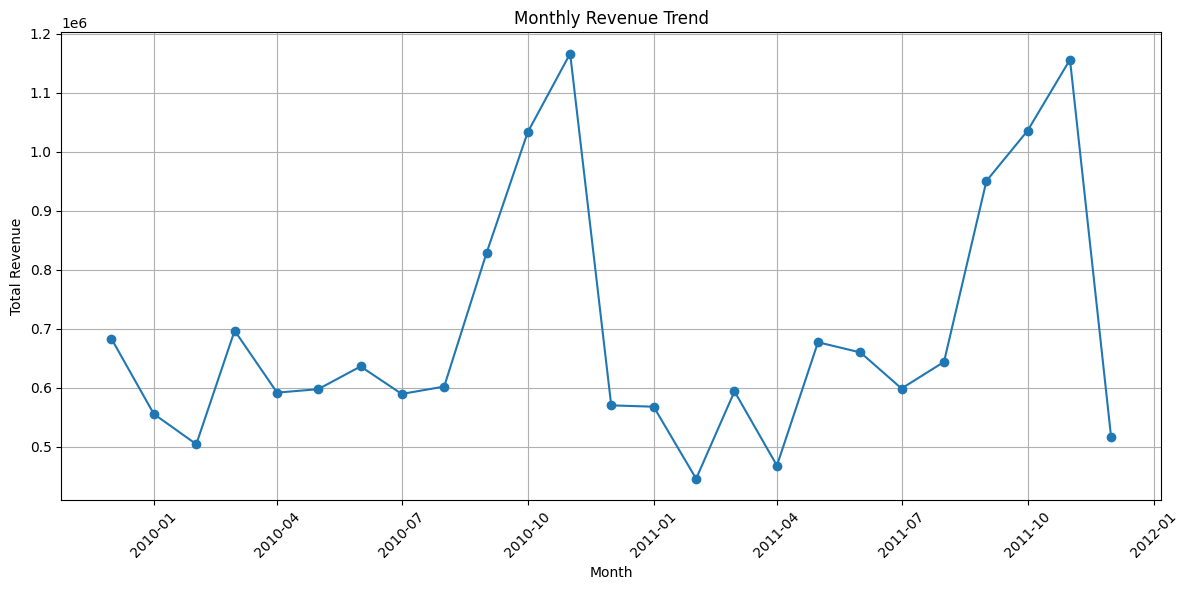

Dashboard visualization saved successfully!


In [43]:
# Save the main dashboard visualizations

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_revenue_dashboard["InvoiceDate"],
    monthly_revenue_dashboard["Revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.savefig("monthly_revenue_trend.png", dpi=300, bbox_inches="tight")
plt.show()

print("Dashboard visualization saved successfully!")

In [44]:
# Automated Business Summary

top_customer_id = customer_revenue.index[0]
top_customer_revenue = customer_revenue.iloc[0]

top_country = country_revenue.index[0]
top_country_revenue = country_revenue.iloc[0]

summary = f"""
ADVANCED BUSINESS DATA ANALYTICS SYSTEM
Automated Business Summary
----------------------------------------

Total Revenue: {total_revenue:,.2f}
Total Quantity Sold: {total_quantity:,}
Total Transactions: {total_transactions:,}
Total Customers: {total_customers:,}

Top Customer:
Customer ID {top_customer_id:.0f}
Revenue: {top_customer_revenue:,.2f}

Top Country:
{top_country}
Revenue: {top_country_revenue:,.2f}

Forecasting Model:
R² Score: {forecast_r2:.4f}
RMSE: {forecast_rmse:,.2f}
"""

print(summary)


ADVANCED BUSINESS DATA ANALYTICS SYSTEM
Automated Business Summary
----------------------------------------

Total Revenue: 17,374,804.27
Total Quantity Sold: 10,513,952
Total Transactions: 36,969
Total Customers: 5,878

Top Customer:
Customer ID 18102
Revenue: 580,987.04

Top Country:
United Kingdom
Revenue: 14,389,234.92

Forecasting Model:
R² Score: -0.1830
RMSE: 262,374.67



In [45]:
# Year-wise Revenue Analysis

yearly_revenue = (
    df.groupby("Year")["Revenue"]
      .sum()
      .sort_index()
)

print("Year-wise Revenue:")
print(yearly_revenue)

Year-wise Revenue:
Year
2009     683504.010
2010    8374496.094
2011    8316804.164
Name: Revenue, dtype: float64


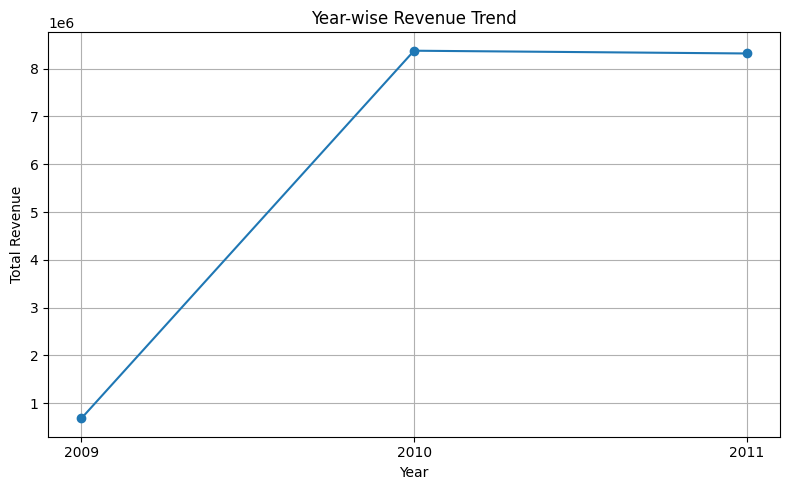

In [46]:
# Year-wise Revenue Trend

plt.figure(figsize=(8, 5))

plt.plot(
    yearly_revenue.index,
    yearly_revenue.values,
    marker="o"
)

plt.title("Year-wise Revenue Trend")
plt.xlabel("Year")
plt.ylabel("Total Revenue")
plt.xticks(yearly_revenue.index)
plt.grid(True)

plt.tight_layout()
plt.show()

In [47]:
# Monthly Revenue Analysis

monthly_trend = (
    df.groupby(df["InvoiceDate"].dt.month)["Revenue"]
      .sum()
)

print("Monthly Revenue:")
print(monthly_trend)

print("\nHighest Revenue Month:",
      monthly_trend.idxmax())

print("Highest Monthly Revenue:",
      monthly_trend.max())

print("\nLowest Revenue Month:",
      monthly_trend.idxmin())

print("Lowest Monthly Revenue:",
      monthly_trend.min())

Monthly Revenue:
InvoiceDate
1     1123903.982
2      950643.876
3     1291060.231
4     1060356.333
5     1275188.530
6     1296417.180
7     1188699.071
8     1246275.640
9     1779704.153
10    2068754.460
11    2322665.632
12    1771135.180
Name: Revenue, dtype: float64

Highest Revenue Month: 11
Highest Monthly Revenue: 2322665.632

Lowest Revenue Month: 2
Lowest Monthly Revenue: 950643.876


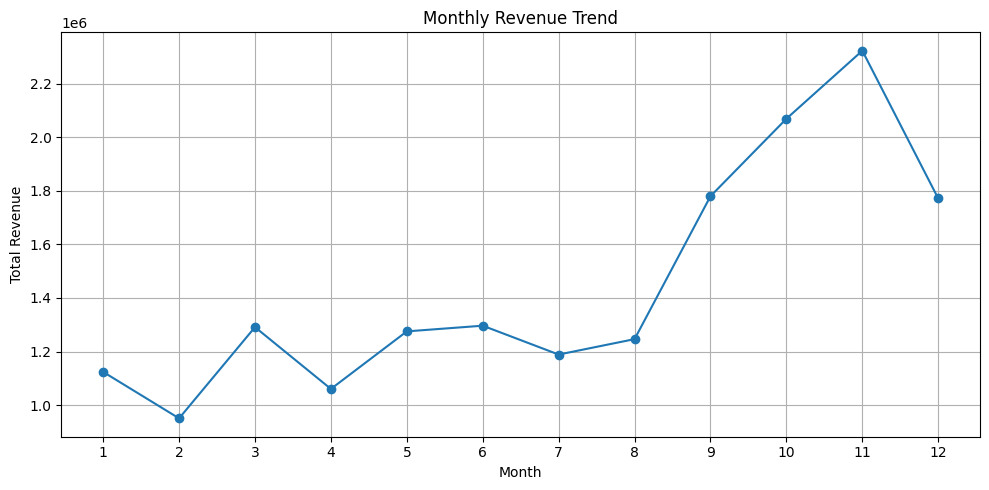

In [48]:
# Monthly Revenue Trend by Month

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_trend.index,
    monthly_trend.values,
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(range(1, 13))
plt.grid(True)

plt.tight_layout()
plt.show()

In [49]:
#Customer Purchase Behavior

customer_transactions = (
    df.groupby("Customer ID")["Invoice"]
      .nunique()
      .sort_values(ascending=False)
)

print("Top 10 Customers by Number of Transactions:")
print(customer_transactions.head(10))

Top 10 Customers by Number of Transactions:
Customer ID
14911.0    398
12748.0    336
17841.0    211
15311.0    208
13089.0    203
14606.0    192
14156.0    156
17850.0    155
14646.0    151
18102.0    145
Name: Invoice, dtype: int64


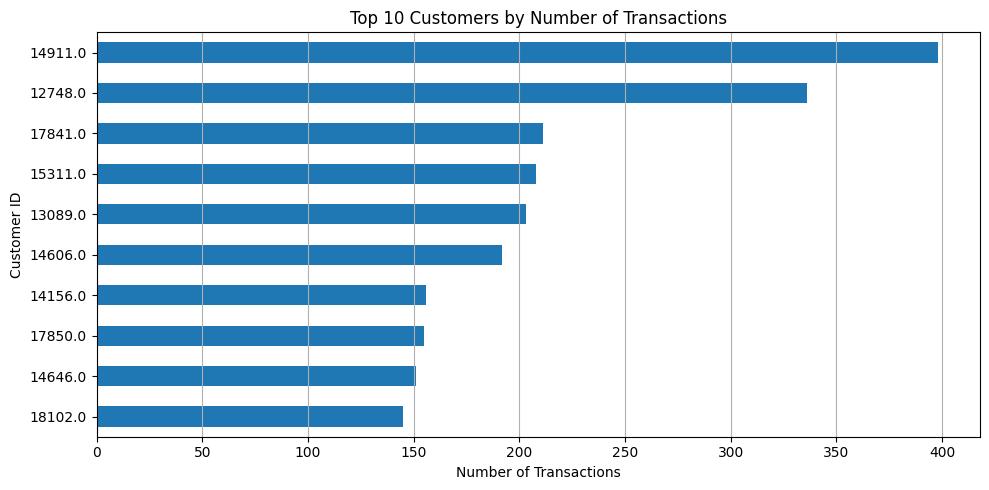

In [50]:
# Top 10 Customers by Number of Transactions

top_customers_transactions = customer_transactions.head(10)

plt.figure(figsize=(10, 5))

top_customers_transactions.sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Customers by Number of Transactions")
plt.xlabel("Number of Transactions")
plt.ylabel("Customer ID")
plt.grid(axis="x")
plt.tight_layout()
plt.show()

In [51]:
# KPI Analysis

total_revenue = df["Revenue"].sum()
total_quantity = df["Quantity"].sum()
total_transactions = df["Invoice"].nunique()
total_customers = df["Customer ID"].nunique()

print("KPI Analysis")
print("-------------------------")
print(f"Total Revenue: {total_revenue:,.2f}")
print(f"Total Quantity Sold: {total_quantity:,}")
print(f"Total Transactions: {total_transactions:,}")
print(f"Total Customers: {total_customers:,}")

KPI Analysis
-------------------------
Total Revenue: 17,374,804.27
Total Quantity Sold: 10,513,952
Total Transactions: 36,969
Total Customers: 5,878


In [52]:
#Customer Revenue Analysis

customer_revenue = (
    df.groupby("Customer ID")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

print("Top 10 Customers by Revenue:")
print(customer_revenue.head(10))

Top 10 Customers by Revenue:
Customer ID
18102.0    580987.04
14646.0    528602.52
14156.0    313437.62
14911.0    291420.81
17450.0    244784.25
13694.0    195640.69
17511.0    172132.87
16446.0    168472.50
16684.0    147142.77
12415.0    144458.37
Name: Revenue, dtype: float64


In [53]:
#Final Business Trend and Customer Insights

highest_revenue_month = monthly_trend.idxmax()
highest_month_revenue = monthly_trend.max()

lowest_revenue_month = monthly_trend.idxmin()
lowest_month_revenue = monthly_trend.min()

top_transaction_customer = customer_transactions.idxmax()
top_transaction_count = customer_transactions.max()

top_revenue_customer = customer_revenue.idxmax()
top_customer_revenue = customer_revenue.max()

print("Task 6 - Final Analysis Summary")
print("--------------------------------------")
print(f"Highest Revenue Month: {highest_revenue_month}")
print(f"Highest Monthly Revenue: {highest_month_revenue:,.2f}")
print(f"Lowest Revenue Month: {lowest_revenue_month}")
print(f"Lowest Monthly Revenue: {lowest_month_revenue:,.2f}")
print(f"Most Frequent Customer: {top_transaction_customer}")
print(f"Number of Transactions: {top_transaction_count}")
print(f"Highest Revenue Customer: {top_revenue_customer}")
print(f"Customer Revenue: {top_customer_revenue:,.2f}")

Task 6 - Final Analysis Summary
--------------------------------------
Highest Revenue Month: 11
Highest Monthly Revenue: 2,322,665.63
Lowest Revenue Month: 2
Lowest Monthly Revenue: 950,643.88
Most Frequent Customer: 14911.0
Number of Transactions: 398
Highest Revenue Customer: 18102.0
Customer Revenue: 580,987.04


In [55]:
# Predictive Insights
# Generate predictions for the test period

y_pred_forecast = forecast_model.predict(X_test_forecast)

forecast_results = pd.DataFrame({
    "Month": test_data["InvoiceDate"],
    "Actual Revenue": y_test_forecast.values,
    "Predicted Revenue": y_pred_forecast
})

print("Actual vs Predicted Revenue:")
print(forecast_results)

Actual vs Predicted Revenue:
        Month  Actual Revenue  Predicted Revenue
20 2011-08-01      644051.040      711077.431038
21 2011-09-01      950690.202      740059.676580
22 2011-10-01     1035642.450      769041.922123
23 2011-11-01     1156205.610      798024.167666
24 2011-12-01      517208.440      827006.413208


In [56]:
# Predictive Insight

forecast_results["Difference"] = (
    forecast_results["Actual Revenue"]
    - forecast_results["Predicted Revenue"]
)

forecast_results["Prediction_Error_%"] = (
    abs(forecast_results["Difference"])
    / forecast_results["Actual Revenue"]
) * 100

print("Predictive Insights")
print("-------------------------")
print(
    "Average Prediction Error: "
    f"{forecast_results['Prediction_Error_%'].mean():.2f}%"
)

print(
    "Highest Actual Revenue: "
    f"{forecast_results['Actual Revenue'].max():,.2f}"
)

print(
    "Highest Predicted Revenue: "
    f"{forecast_results['Predicted Revenue'].max():,.2f}"
)

Predictive Insights
-------------------------
Average Prediction Error: 29.84%
Highest Actual Revenue: 1,156,205.61
Highest Predicted Revenue: 827,006.41


In [57]:
# Business Recommendations

print("Business Recommendations")
print("--------------------------------------")

print("1. Focus on high-revenue months, especially November.")
print("2. Prepare inventory and marketing campaigns before peak periods.")
print("3. Monitor customer purchasing frequency to retain high-value customers.")
print("4. Give special attention to customers generating high revenue.")
print("5. Use predictive forecasting as a planning support tool.")
print("6. Improve forecasting accuracy by using more advanced time-series models.")

Business Recommendations
--------------------------------------
1. Focus on high-revenue months, especially November.
2. Prepare inventory and marketing campaigns before peak periods.
3. Monitor customer purchasing frequency to retain high-value customers.
4. Give special attention to customers generating high revenue.
5. Use predictive forecasting as a planning support tool.
6. Improve forecasting accuracy by using more advanced time-series models.


In [58]:
#Complete Analytics Workflow

workflow = """
Advanced Business Data Analytics Workflow

1. Business Dataset Collection
   ↓
2. Data Ingestion
   ↓
3. Data Cleaning & Preprocessing
   ↓
4. Feature Engineering
   ↓
5. Exploratory Data Analysis
   ↓
6. KPI & Trend Analysis
   ↓
7. Customer Behavior Analysis
   ↓
8. Predictive Analytics
   ↓
9. Model Evaluation
   ↓
10. Predictive Insights
   ↓
11. Business Recommendations
   ↓
12. Dashboard & Report Generation
"""

print(workflow)


Advanced Business Data Analytics Workflow

1. Business Dataset Collection
   ↓
2. Data Ingestion
   ↓
3. Data Cleaning & Preprocessing
   ↓
4. Feature Engineering
   ↓
5. Exploratory Data Analysis
   ↓
6. KPI & Trend Analysis
   ↓
7. Customer Behavior Analysis
   ↓
8. Predictive Analytics
   ↓
9. Model Evaluation
   ↓
10. Predictive Insights
   ↓
11. Business Recommendations
   ↓
12. Dashboard & Report Generation



In [59]:
# Complete Analytics Workflow and Architecture

workflow = """
============================================================
     ADVANCED BUSINESS DATA ANALYTICS SYSTEM
              ANALYTICS WORKFLOW
============================================================

1. DATASET COLLECTION
   └── Collect large-scale retail business transaction data

                         ↓

2. DATA INGESTION
   └── Load and combine source data using Pandas

                         ↓

3. DATA PREPROCESSING
   ├── Remove duplicate records
   ├── Handle missing values
   ├── Remove invalid quantity and price values
   └── Validate data quality

                         ↓

4. FEATURE ENGINEERING
   ├── Calculate Revenue
   ├── Extract Year, Month and Quarter
   ├── Extract Day and Day of Week
   ├── Extract Hour
   └── Create Weekend indicator

                         ↓

5. EXPLORATORY DATA ANALYSIS
   ├── Revenue trends
   ├── Sales patterns
   ├── Customer analysis
   └── Country-wise analysis

                         ↓

6. KPI & TREND ANALYSIS
   ├── Total Revenue
   ├── Total Quantity Sold
   ├── Total Transactions
   ├── Total Customers
   └── Monthly and yearly trends

                         ↓

7. CUSTOMER BEHAVIOR ANALYSIS
   ├── Customer transaction frequency
   ├── Customer revenue contribution
   └── Top customers identification

                         ↓

8. PREDICTIVE ANALYTICS
   └── Develop revenue forecasting model
       using Scikit-learn

                         ↓

9. MODEL EVALUATION
   ├── R² Score
   └── RMSE

                         ↓

10. PREDICTIVE INSIGHTS
    ├── Actual vs predicted revenue
    ├── Prediction error analysis
    └── Forecasting observations

                         ↓

11. BUSINESS RECOMMENDATIONS
    ├── Identify high-revenue periods
    ├── Focus on high-value customers
    ├── Support inventory and marketing planning
    └── Improve future forecasting accuracy

                         ↓

12. DASHBOARD & REPORT GENERATION
    ├── Visualizations
    ├── KPI summaries
    ├── Business insights
    └── Final project documentation

============================================================
                END OF ANALYTICS WORKFLOW
============================================================
"""

print(workflow)


     ADVANCED BUSINESS DATA ANALYTICS SYSTEM
              ANALYTICS WORKFLOW

1. DATASET COLLECTION
   └── Collect large-scale retail business transaction data

                         ↓

2. DATA INGESTION
   └── Load and combine source data using Pandas

                         ↓

3. DATA PREPROCESSING
   ├── Remove duplicate records
   ├── Handle missing values
   ├── Remove invalid quantity and price values
   └── Validate data quality

                         ↓

4. FEATURE ENGINEERING
   ├── Calculate Revenue
   ├── Extract Year, Month and Quarter
   ├── Extract Day and Day of Week
   ├── Extract Hour
   └── Create Weekend indicator

                         ↓

5. EXPLORATORY DATA ANALYSIS
   ├── Revenue trends
   ├── Sales patterns
   ├── Customer analysis
   └── Country-wise analysis

                         ↓

6. KPI & TREND ANALYSIS
   ├── Total Revenue
   ├── Total Quantity Sold
   ├── Total Transactions
   ├── Total Customers
   └── Monthly and yearly trends

          